In [8]:
import pandas as pd

In [9]:
ARQUIVO_CSV = "resultados_total.csv"

In [10]:
df = pd.read_csv(ARQUIVO_CSV, sep=";")

# Remove espaços extras dos nomes das colunas
df.columns = df.columns.str.strip()

print(df.head())

        seed  temp_inicial  temp_final  alpha  iteracoes_por_temp  operador  \
0  159768904         500.0       0.001    0.9                   1         0   
1  230236244         500.0       0.001    0.9                   1         0   
2  291940609         500.0       0.001    0.9                   1         0   
3  356008268         500.0       0.001    0.9                   1         0   
4  435864008         500.0       0.001    0.9                   1         0   

   final_losses  visited  total_iteracoes  tempo_execucao  
0    215.053509      437              125        0.049509  
1    214.545552      465              125        0.047504  
2    214.448520      404              125        0.048980  
3    213.941448      419              125        0.056221  
4    214.473918      440              125        0.049237  


In [12]:
# =========================================
# CÉLULA 5 - CONFIGURAÇÕES E MÉTRICAS
# =========================================

config_cols = [
    "temp_inicial",
    "temp_final",
    "alpha",
    "iteracoes_por_temp",
    "operador"
]

metricas = [
    "final_losses",
    "visited",
    "total_iteracoes",
    "tempo_execucao"
]

In [13]:
# =========================================
# CÉLULA 6 - MÉDIA E DESVIO PADRÃO
# =========================================

resultado = (
    df.groupby(config_cols)[metricas]
    .agg(["mean", "std"])
    .reset_index()
)

# Ajusta nomes das colunas
resultado.columns = [
    "_".join(col).strip("_")
    for col in resultado.columns.values
]

print(resultado.head())

   temp_inicial  temp_final  alpha  iteracoes_por_temp  operador  \
0         500.0       0.001    0.9                   1         0   
1         500.0       0.001    0.9                   1         1   
2         500.0       0.001    0.9                   1         2   
3         500.0       0.001    0.9                  10         0   
4         500.0       0.001    0.9                  10         1   

   final_losses_mean  final_losses_std  visited_mean  visited_std  \
0         214.498773          1.007524        435.00    20.652514   
1         213.848139          0.324757        377.00    29.616852   
2         214.162122          0.411758        421.20    28.614682   
3         213.490687          0.017881       1948.15    60.894451   
4         213.480636          0.002357       1733.90    52.308699   

   total_iteracoes_mean  total_iteracoes_std  tempo_execucao_mean  \
0                 125.0                  0.0             0.049489   
1                 125.0               

In [15]:
# =========================================
# CÉLULA 7 - RANKING COM CRITÉRIOS
# =========================================

ranking = (
    resultado.sort_values(
        by=[
            "final_losses_mean",     # 1. menor perda média
            "final_losses_std",      # 2. menor desvio padrão
            "total_iteracoes_mean",  # 3. menor quantidade de interações
            "visited_mean"           # 4. menor média de visitados
        ],
        ascending=[True, True, True, True]
    )
    .reset_index(drop=True)
)

ranking["ranking"] = ranking.index + 1

print(ranking.head())

   temp_inicial  temp_final  alpha  iteracoes_por_temp  operador  \
0        2500.0       0.001  0.990                   1         1   
1         500.0       0.001  0.950                  10         1   
2        1000.0       0.001  0.950                  10         1   
3        2500.0       0.001  0.950                  10         1   
4         500.0       0.001  0.975                  10         1   

   final_losses_mean  final_losses_std  visited_mean  visited_std  \
0         213.479926               0.0       1998.30    61.896433   
1         213.479926               0.0       2528.45    66.166835   
2         213.479926               0.0       2655.50    69.637029   
3         213.479926               0.0       2822.30    54.150959   
4         213.479926               0.0       3354.75    36.913662   

   total_iteracoes_mean  total_iteracoes_std  tempo_execucao_mean  \
0                1466.0                  0.0             0.205910   
1                2560.0               

In [16]:
# =========================================
# CÉLULA 8 - TOP 20 CONFIGURAÇÕES
# =========================================

top20 = ranking[
    [
        "ranking",
        "temp_inicial",
        "temp_final",
        "alpha",
        "iteracoes_por_temp",
        "operador",
        "final_losses_mean",
        "final_losses_std",
        "visited_mean",
        "visited_std",
        "total_iteracoes_mean",
        "tempo_execucao_mean"
    ]
].head(20)

print("\n===== TOP 20 CONFIGURAÇÕES =====\n")

display(top20)


===== TOP 20 CONFIGURAÇÕES =====



,ranking,temp_inicial,temp_final,alpha,iteracoes_por_temp,operador,final_losses_mean,final_losses_std,visited_mean,visited_std,total_iteracoes_mean,tempo_execucao_mean
0,1,2500.0,0.001,0.990,1,1,213.479926,0.0,1998.30,61.896433,1466.0,0.205910
1,2,500.0,0.001,0.950,10,1,213.479926,0.0,2528.45,66.166835,2560.0,0.257808
2,3,1000.0,0.001,0.950,10,1,213.479926,0.0,2655.50,69.637029,2700.0,0.269142
3,4,2500.0,0.001,0.950,10,1,213.479926,0.0,2822.30,54.150959,2880.0,0.295065
4,5,500.0,0.001,0.975,10,1,213.479926,0.0,3354.75,36.913662,5190.0,0.754952
5,6,1000.0,0.001,0.975,10,1,213.479926,0.0,3468.40,46.641296,5460.0,0.665251
6,7,1000.0,0.001,0.975,10,2,213.479926,0.0,3575.20,37.724207,5460.0,0.689108
7,8,2500.0,0.001,0.975,10,1,213.479926,0.0,3604.90,33.197812,5820.0,0.748250
8,9,2500.0,0.001,0.975,10,2,213.479926,0.0,3692.25,29.486616,5820.0,0.763118
9,10,5000.0,0.001,0.975,10,1,213.479926,0.0,3684.05,39.940054,6100.0,0.695986


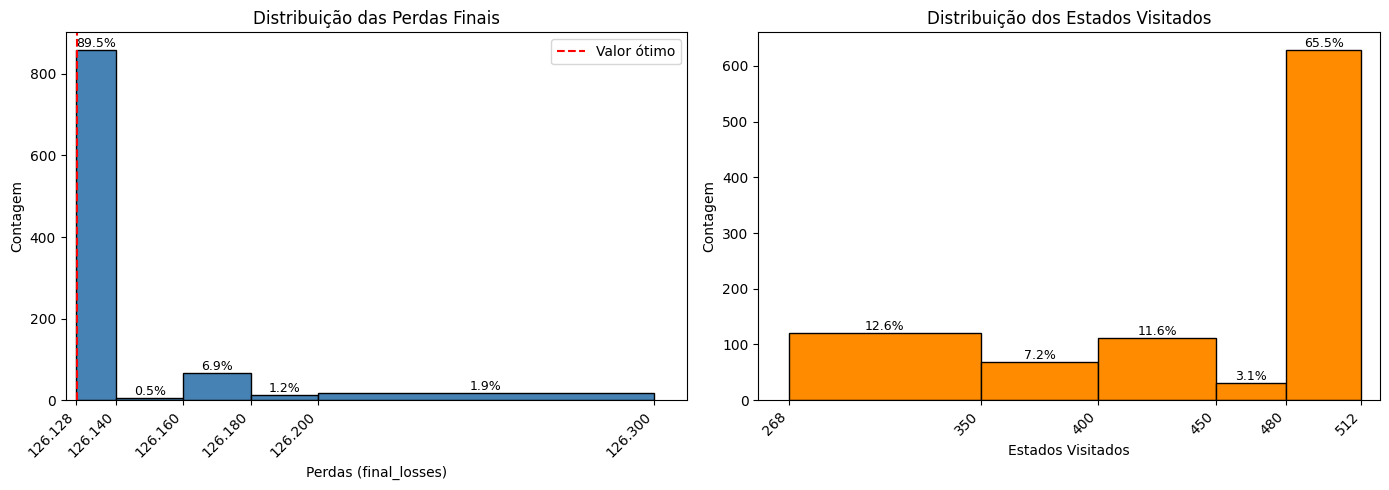

Salvo em histogramas.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../results/resultados_14_barras.csv', sep=';', skipinitialspace=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma 1 - Perdas
bins_losses = [126.128, 126.140, 126.160, 126.180, 126.200, 126.300]
ax1.hist(df['final_losses'], bins=bins_losses, color='steelblue', edgecolor='black')
ax1.set_xlim(126.125, 126.310)  # afasta do eixo y
ax1.set_xticks(bins_losses)
ax1.set_xticklabels(['126.128', '126.140', '126.160', '126.180', '126.200', '126.300'])
ax1.set_xlabel('Perdas (final_losses)')
ax1.set_ylabel('Contagem')
ax1.set_title('Distribuição das Perdas Finais')
ax1.axvline(x=126.128447, color='red', linestyle='--', linewidth=1.5, label='Valor ótimo')
ax1.legend()
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# porcentagem em cima de cada barra
for rect in ax1.patches:
    height = rect.get_height()
    if height > 0:
        ax1.text(rect.get_x() + rect.get_width()/2., height,
                f'{height/len(df)*100:.1f}%',
                ha='center', va='bottom', fontsize=9)

# Histograma 2 - Estados visitados
bins_visited = [268, 350, 400, 450, 480, 512]
ax2.hist(df['visited'], bins=bins_visited, color='darkorange', edgecolor='black')
ax2.set_xlim(255, 520)  # afasta do eixo y
ax2.set_xticks(bins_visited)
ax2.set_xlabel('Estados Visitados')
ax2.set_ylabel('Contagem')
ax2.set_title('Distribuição dos Estados Visitados')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# porcentagem em cima de cada barra
for rect in ax2.patches:
    height = rect.get_height()
    if height > 0:
        ax2.text(rect.get_x() + rect.get_width()/2., height,
                f'{height/len(df)*100:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('histogramas.png', dpi=150)
plt.show()

print("Salvo em histogramas.png")

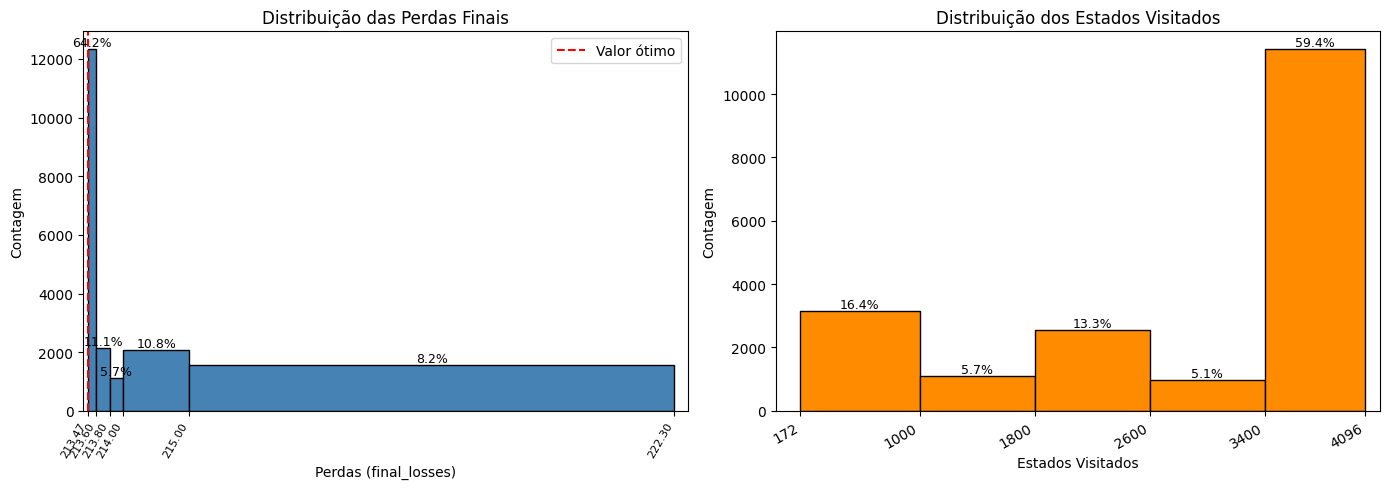

Salvo em histogramas_30_barras.png


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../results/resultados_30_barras.csv', sep=';', skipinitialspace=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma 1 - Perdas
bins_losses = [213.47, 213.60, 213.80, 214.00, 215.00, 222.30]
labels_losses = ['213.47', '213.60', '213.80', '214.00', '215.00', '222.30']
ax1.hist(df['final_losses'], bins=bins_losses, color='steelblue', edgecolor='black')
ax1.set_xlim(213.40, 222.50)
ax1.set_xticks(bins_losses)
ax1.set_xticklabels(labels_losses, rotation=60, ha='right', fontsize=8)
ax1.set_xlabel('Perdas (final_losses)')
ax1.set_ylabel('Contagem')
ax1.set_title('Distribuição das Perdas Finais')
ax1.axvline(x=213.479926, color='red', linestyle='--', linewidth=1.5, label='Valor ótimo')
ax1.legend()

for rect in ax1.patches:
    height = rect.get_height()
    if height > 0:
        ax1.text(rect.get_x() + rect.get_width()/2., height,
                f'{height/len(df)*100:.1f}%',
                ha='center', va='bottom', fontsize=9)

# Histograma 2 - Estados visitados
bins_visited = [172, 1000, 1800, 2600, 3400, 4096]
labels_visited = ['172', '1000', '1800', '2600', '3400', '4096']
ax2.hist(df['visited'], bins=bins_visited, color='darkorange', edgecolor='black')
ax2.set_xlim(0, 4200)
ax2.set_xticks(bins_visited)
ax2.set_xticklabels(labels_visited, rotation=30, ha='right')
ax2.set_xlabel('Estados Visitados')
ax2.set_ylabel('Contagem')
ax2.set_title('Distribuição dos Estados Visitados')

for rect in ax2.patches:
    height = rect.get_height()
    if height > 0:
        ax2.text(rect.get_x() + rect.get_width()/2., height,
                f'{height/len(df)*100:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('histogramas_30_barras.png', dpi=150)
plt.show()

print("Salvo em histogramas_30_barras.png")

In [19]:
import pandas as pd

df = pd.read_csv('../results/resultados_57_barras.csv', sep=';', skipinitialspace=True)

print("Perdas:")
print(df['final_losses'].describe())
print("\nEstados visitados:")
print(df['visited'].describe())

Perdas:
count    120.000000
mean     645.494199
std        1.824596
min      642.587915
25%      642.655479
50%      646.603953
75%      646.617501
max      648.121751
Name: final_losses, dtype: float64

Estados visitados:
count      120.000000
mean     30358.833333
std       3282.331794
min      24219.000000
25%      28304.750000
50%      30320.500000
75%      33033.250000
max      36526.000000
Name: visited, dtype: float64


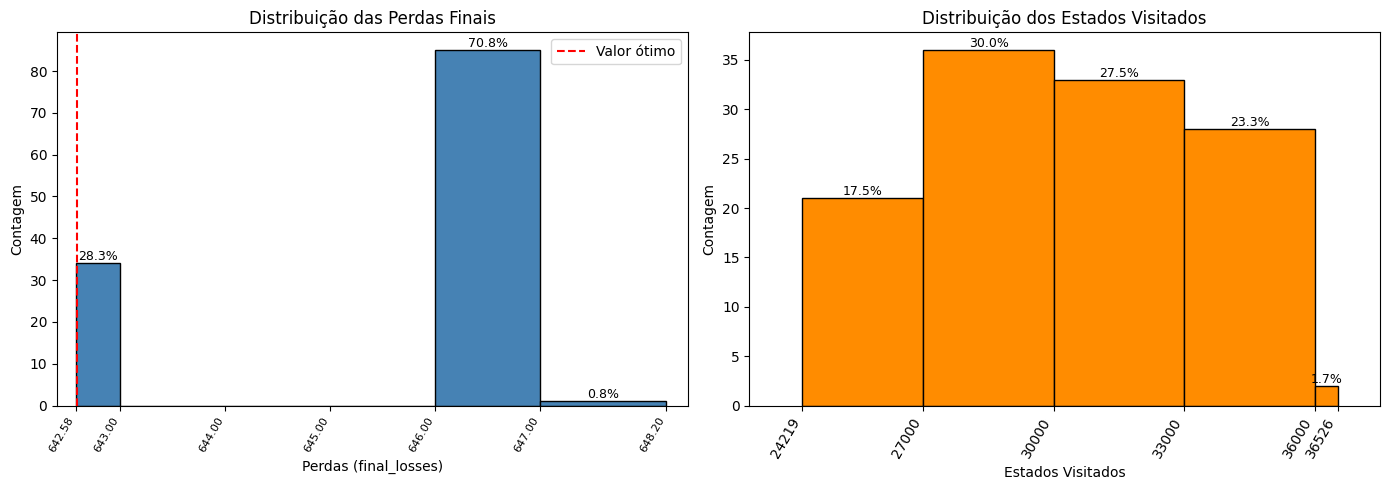

Salvo em histogramas_57_barras.png


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../results/resultados_57_barras.csv', sep=';', skipinitialspace=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma 1 - Perdas
bins_losses = [642.58, 643.00, 644.00, 645.00, 646.00, 647.00, 648.20]
labels_losses = ['642.58', '643.00', '644.00', '645.00', '646.00', '647.00', '648.20']
ax1.hist(df['final_losses'], bins=bins_losses, color='steelblue', edgecolor='black')
ax1.set_xlim(642.40, 648.40)
ax1.set_xticks(bins_losses)
ax1.set_xticklabels(labels_losses, rotation=60, ha='right', fontsize=8)
ax1.set_xlabel('Perdas (final_losses)')
ax1.set_ylabel('Contagem')
ax1.set_title('Distribuição das Perdas Finais')
ax1.axvline(x=642.587915, color='red', linestyle='--', linewidth=1.5, label='Valor ótimo')
ax1.legend()

for rect in ax1.patches:
    height = rect.get_height()
    if height > 0:
        ax1.text(rect.get_x() + rect.get_width()/2., height,
                f'{height/len(df)*100:.1f}%',
                ha='center', va='bottom', fontsize=9)

# Histograma 2 - Estados visitados
bins_visited = [24219, 27000, 30000, 33000, 36000, 36526]
labels_visited = ['24219', '27000', '30000', '33000', '36000', '36526']
ax2.hist(df['visited'], bins=bins_visited, color='darkorange', edgecolor='black')
ax2.set_xlim(23000, 37500)
ax2.set_xticks(bins_visited)
ax2.set_xticklabels(labels_visited, rotation=60, ha='right')
ax2.set_xlabel('Estados Visitados')
ax2.set_ylabel('Contagem')
ax2.set_title('Distribuição dos Estados Visitados')

for rect in ax2.patches:
    height = rect.get_height()
    if height > 0:
        ax2.text(rect.get_x() + rect.get_width()/2., height,
                f'{height/len(df)*100:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('histogramas_57_barras.png', dpi=150)
plt.show()

print("Salvo em histogramas_57_barras.png")